# Preparation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#import umap
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import Isomap
from matplotlib.patches import Patch
from sklearn.decomposition import PCA
from sklearn.decomposition import SparsePCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

In [28]:
ge_matched = pd.read_csv(r"C:\Users\Juli\Documents\Master\Projekt Genomforschung\projekt_genomforschung\GeAndCancertype.csv", index_col=0)

In [29]:
ge_matched.head()

,SequencingID,ModelID,TSPAN6 (7105),SCYL3 (57147),BAD (572),LAP3 (51056),SNX11 (29916),CASP10 (843),CFLAR (8837),FKBP4 (2288),...,CHMP4A (29082),POLG2 (11232),RBM15B (29890),MRPL12 (6182),IKBKE (9641),DUSP14 (11072),PIP4K2B (8396),SANGER_MODEL_ID,CANCER_TYPE,META_CANCERTYPE
0,CDS-010xbm,ACH-001113,4.956577,3.179411,5.585888,4.856592,4.772382,2.296313,5.424482,6.670500,...,6.106993,5.376176,3.781716,5.136060,0.109694,5.508574,4.871706,SIDM01226,Unknown,Other
1,CDS-02TzJp,ACH-001289,4.954992,2.783576,6.156599,6.250399,4.671135,0.435660,4.823897,6.363479,...,6.519867,4.233543,4.201579,5.594133,0.785037,5.485163,4.834484,NaN,Unknown,Other
2,CDS-0693hw,ACH-001339,3.421952,2.615880,5.096717,6.269129,4.636549,1.269165,5.080769,5.556880,...,5.620372,3.471266,3.439807,6.475904,2.395142,5.904340,4.273322,SIDM00514,Unknown,Other
3,CDS-07Plat,ACH-001619,5.196729,2.144996,5.558329,4.844245,3.838508,2.290548,5.059550,5.065870,...,5.518346,3.973556,3.831816,7.464897,2.988021,5.422105,4.581984,NaN,Unknown,Other
4,CDS-08FOcu,ACH-001979,4.651643,2.454515,5.053415,7.138825,4.414575,2.354303,4.990197,5.049112,...,6.384074,2.434762,3.957525,4.427103,2.109839,5.237908,4.540963,NaN,Unknown,Other


In [4]:
category_map = {
    # Hematologic (Blood & Lymph)
    'T-Lymphoblastic Leukemia': 'Blood/Lymph',
    'Acute Myeloid Leukemia': 'Blood/Lymph',
    'Chronic Myelogenous Leukemia': 'Blood/Lymph',
    'B-Lymphoblastic Leukemia': 'Blood/Lymph',
    'Plasma Cell Myeloma': 'Blood/Lymph',
    "T-Cell Non-Hodgkin's Lymphoma": 'Blood/Lymph',
    "B-Cell Non-Hodgkin's Lymphoma": 'Blood/Lymph',
    "Burkitt's Lymphoma": 'Blood/Lymph',
    "Hodgkin's Lymphoma": 'Blood/Lymph',
    'Other Blood Cancers': 'Blood/Lymph',

    # Gastrointestinal (GI Tract)
    'Colorectal Carcinoma': 'Gastrointestinal',
    'Gastric Carcinoma': 'Gastrointestinal',
    'Pancreatic Carcinoma': 'Gastrointestinal',
    'Hepatocellular Carcinoma': 'Gastrointestinal',
    'Biliary Tract Carcinoma': 'Gastrointestinal',
    'Esophageal Carcinoma': 'Gastrointestinal',
    'Esophageal Squamous Cell Carcinoma': 'Gastrointestinal',

    # Thoracic (Lung & Chest)
    'Non-Small Cell Lung Carcinoma': 'Thoracic',
    'Squamous Cell Lung Carcinoma': 'Thoracic',
    'Small Cell Lung Carcinoma': 'Thoracic',
    'Mesothelioma': 'Thoracic',

    # Sarcomas (Bone & Soft Tissue)
    "Ewing's Sarcoma": 'Sarcoma/Bone',
    'Osteosarcoma': 'Sarcoma/Bone',
    'Chondrosarcoma': 'Sarcoma/Bone',
    'Rhabdomyosarcoma': 'Sarcoma/Bone',
    'Other Sarcomas': 'Sarcoma/Bone',

    # CNS (Brain)
    'Glioblastoma': 'CNS',
    'Glioma': 'CNS',
    'Neuroblastoma': 'CNS', # Oft PNS, aber meist mit ZNS gruppiert

    # Gynecologic / Urologic
    'Ovarian Carcinoma': 'Uro/Gyn',
    'Cervical Carcinoma': 'Uro/Gyn',
    'Endometrial Carcinoma': 'Uro/Gyn',
    'Breast Carcinoma': 'Uro/Gyn',
    'Prostate Carcinoma': 'Uro/Gyn',
    'Bladder Carcinoma': 'Uro/Gyn',
    'Kidney Carcinoma': 'Uro/Gyn',

    # Head & Neck / Skin / Endocrine
    'Melanoma': 'Skin/HNSC',
    'Head and Neck Carcinoma': 'Skin/HNSC',
    'Oral Cavity Carcinoma': 'Skin/HNSC',
    'Thyroid Gland Carcinoma': 'Skin/HNSC',

    # Others
    'Non-Cancerous': 'Control',
    'Other Solid Cancers': 'Other'
}
# Anwendung auf den DataFrame
#df['META_CANCERTYPE'] = df['CANCER_TYPE'].map(category_map).fillna('Other')
ge_matched['META_CANCERTYPE'] = ge_matched['CANCER_TYPE'].map(category_map).fillna('Other')

Generate a personalized color palette


In [30]:
# get unique categories for color mapping
unique_categories = sorted(ge_matched['META_CANCERTYPE'].unique())

# generate a color palette with as many colors as unique categories
base_colors = sns.color_palette("Set1", len(unique_categories))
color_dict = dict(zip(unique_categories, base_colors))

# color coding for "Other" and "Control"
if 'Other' in color_dict:
    color_dict['Other'] = '#d3d3d3'

if 'Control' in color_dict:
    color_dict['Control'] = '#7f7f7f'

# Visualize the relationship between gene expression and drug response


## t-SNE


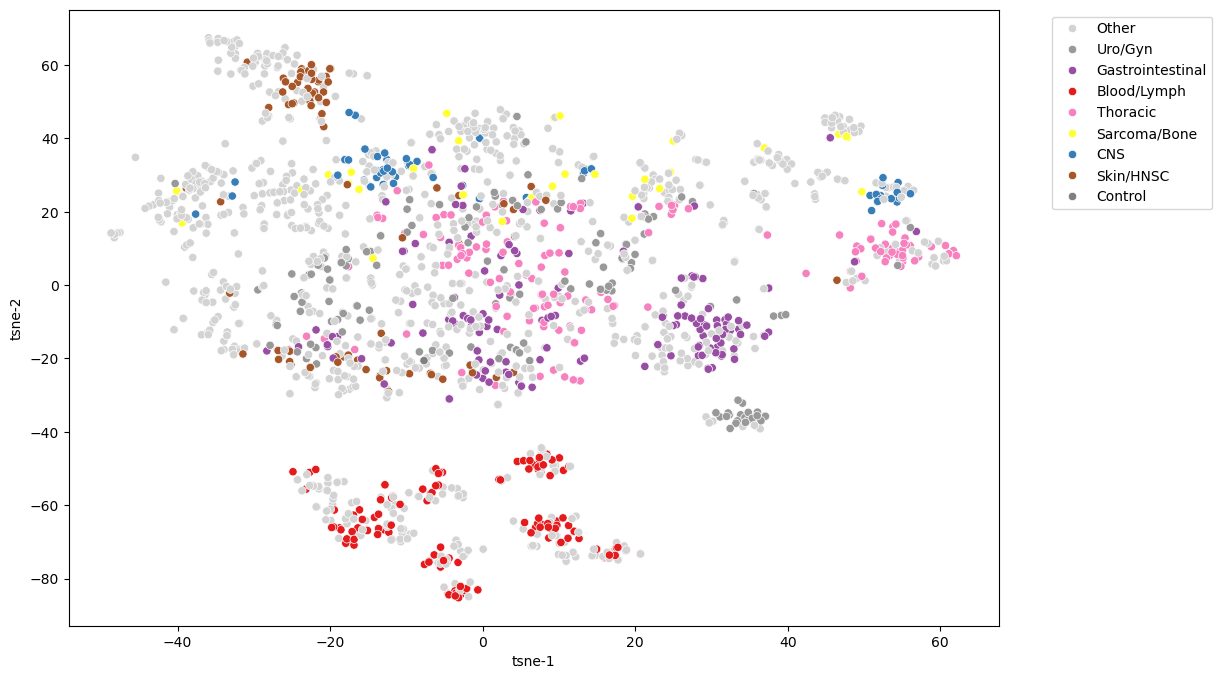

In [9]:
# selection of features for t-SNE (only gene columns)
#gene_features = master_df.drop_duplicates(subset=['ModelID']).filter(regex='\(.*\)')
gene_features = ge_matched.iloc[: , 2:980]

# treat missing values (t-SNE does not allow NaNs)
gene_features = gene_features.fillna(gene_features.mean())

# standardize the data (mean=0, variance=1)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(gene_features)

# perplexity is important hyperparameter (usually between 5 and 50)
tsne = TSNE(n_components=2, perplexity=15, init='pca', learning_rate='auto')
tsne_results = tsne.fit_transform(scaled_data)
# write the t-SNE results back into the DataFrame for plotting
clean_df = gene_features.dropna(subset=gene_features.columns).copy()
clean_df['tsne-1'] = tsne_results[:, 0]
clean_df['tsne-2'] = tsne_results[:, 1]
clean_df['META_CANCERTYPE'] = ge_matched['META_CANCERTYPE'].values

# plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x="tsne-1", y="tsne-2",
    hue="META_CANCERTYPE",
    palette=color_dict,
    data=clean_df,
    legend="full")

plt.title('')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## IsoMap testing


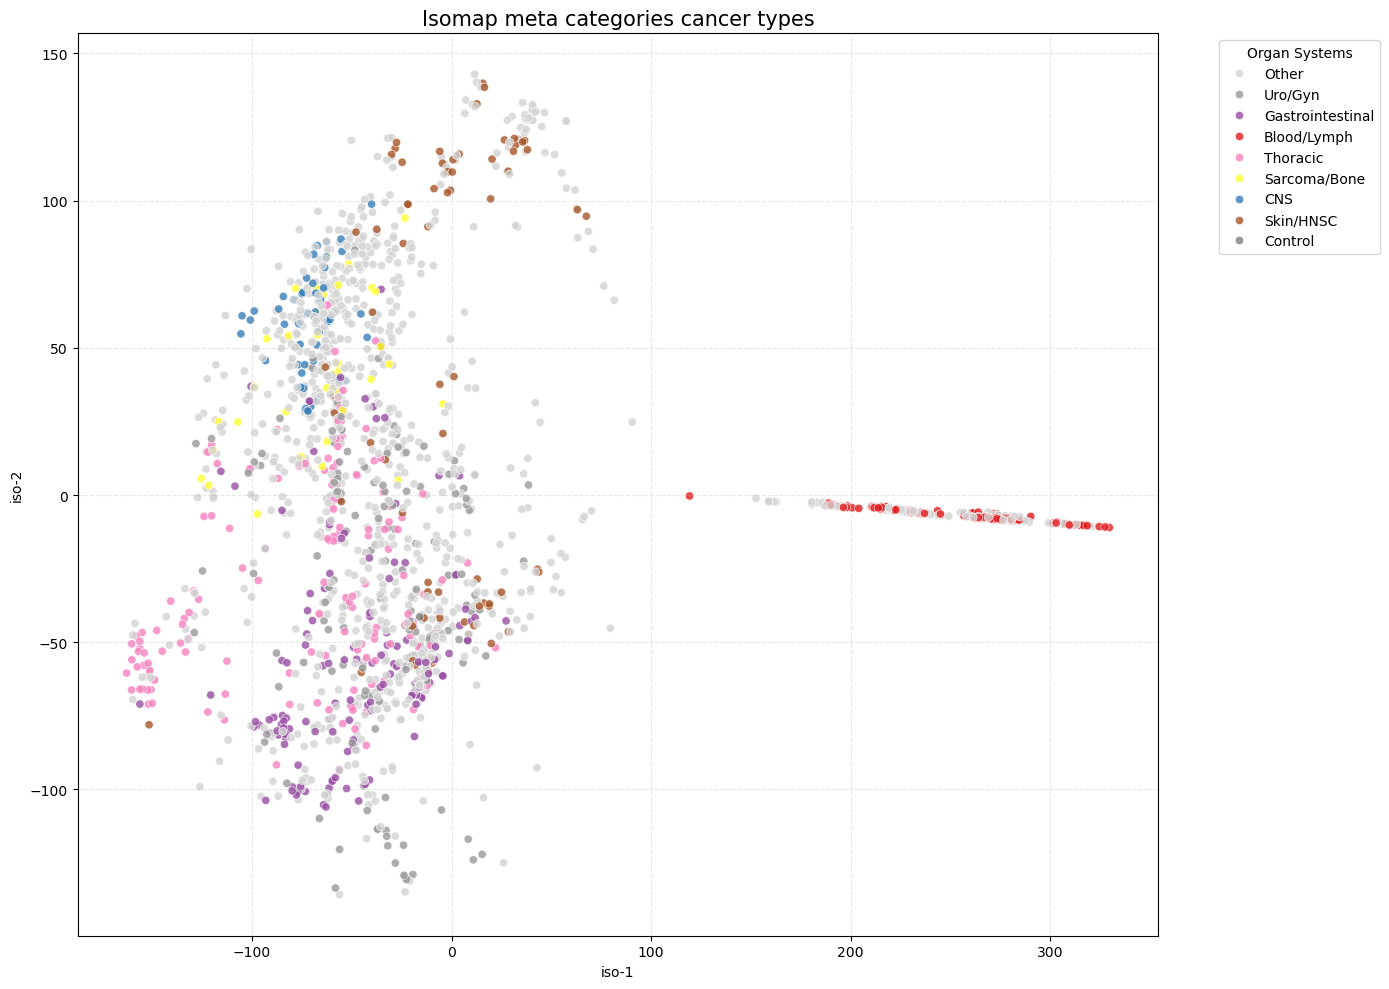

In [10]:
embedding = Isomap(n_components=2,  n_neighbors=10)
X_transformed = embedding.fit_transform(ge_matched.iloc[: , 2:980])  # assuming the first two columns are non-gene features
iso_df = pd.DataFrame(X_transformed, columns=['iso-1', 'iso-2'])
iso_df['META_CANCERTYPE'] = ge_matched['META_CANCERTYPE'].values
plt.figure(figsize=(14, 10))
sns.scatterplot(
    x='iso-1', y='iso-2', 
    hue='META_CANCERTYPE', 
    data=iso_df, 
    palette=color_dict, # personalized color dictionary
    alpha=0.8,
    edgecolor='w',
    linewidth=0.5
)

# legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Organ Systems')
plt.title("Isomap meta categories cancer types", fontsize=15)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()
ge_filtered = ge_matched[ge_matched['META_CANCERTYPE'] != 'Other'].copy()

In [32]:
embedding = Isomap(n_neighbors=5, metric='cosine')
X_transformed_filtered = embedding.fit_transform(ge_filtered.iloc[: , 2:980])
iso_df_filtered = pd.DataFrame(X_transformed_filtered, columns=['iso-1', 'iso-2'])
iso_df_filtered['META_CANCERTYPE'] = ge_filtered['META_CANCERTYPE'].values

# Update the color dictionary (excluding ‘Other’)
unique_categories_filtered = sorted(iso_df_filtered['META_CANCERTYPE'].unique())
colors_filtered = sns.color_palette("Set1", len(unique_categories_filtered))
color_dict_filtered = dict(zip(unique_categories_filtered, colors_filtered))
if 'Control' in color_dict_filtered:
    color_dict_filtered['Control'] = '#7f7f7f'

c:\Users\Juli\anaconda3\envs\my-rdkit-env\Lib\site-packages\sklearn\manifold\_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 3 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
c:\Users\Juli\anaconda3\envs\my-rdkit-env\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
c:\Users\Juli\anaconda3\envs\my-rdkit-env\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
c:\Users\Juli\anaconda3\envs\my-rdkit-env\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more effic

In [ ]:
plt.figure(figsize=(14, 10))
sns.scatterplot(x='iso-1', y='iso-2', hue='META_CANCERTYPE',
                data=iso_df_filtered, palette=color_dict_filtered)
plt.title("Isomap: Focused Biological Clusters (Excl. 'Other')", fontsize=15)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()

## PCA


Irgendwie ist die normale PCA nicht so das wahre, also probiere ich nochmal SparsePCA und KernelPCA

SparsePCA: can produce a principal component that involves only a few genes, so researchers can focus on these specific genes for further analysis

KernelPCA: ??

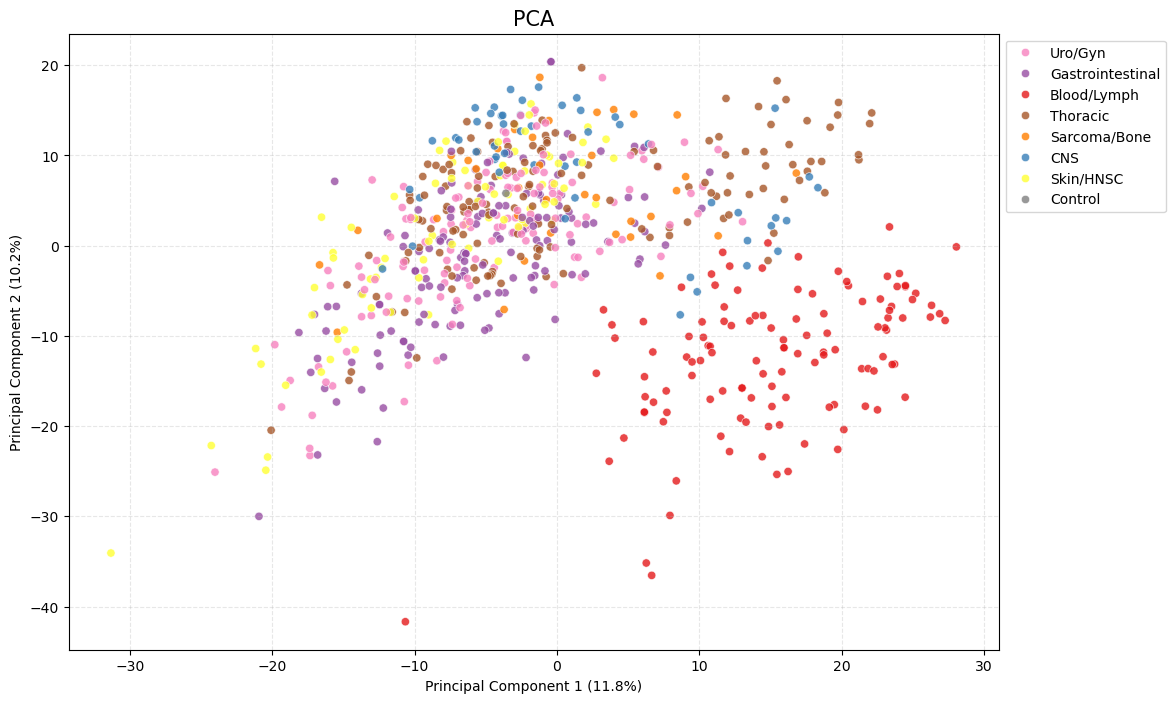

In [14]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(ge_filtered.iloc[: , 2:980])

pca = PCA(n_components=5)
pca_results = pca.fit_transform(scaled_data)

pca_plot_df = pd.DataFrame(data=pca_results, 
                           columns=['PC1', 'PC2', 'PCA3', 'PCA4', 'PCA5'])
pca_plot_df['META_CANCERTYPE'] = ge_filtered['META_CANCERTYPE'].values

exp_var = pca.explained_variance_ratio_ * 100

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='META_CANCERTYPE', 
    data=pca_plot_df,
    palette=color_dict_filtered,
    alpha=0.8,
    edgecolor='w'
)

plt.title(f"PCA", fontsize=15)
plt.xlabel(f"Principal Component 1 ({exp_var[0]:.1f}%)")
plt.ylabel(f"Principal Component 2 ({exp_var[1]:.1f}%)")
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

## UMAP

In [4]:
sns.set(style='white', context='notebook', rc={'figure.figsize':(14,10)})

### 2-dimensional

In [5]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean')
scaled_data = StandardScaler().fit_transform(ge_matched.iloc[: , 2:980])

In [6]:
embedding = reducer.fit_transform(scaled_data)
embedding.shape

(1754, 2)

In [15]:
pca_plot_df = pd.DataFrame()

pca_plot_df['umap-1'] = embedding[:, 0]
pca_plot_df['umap-2'] = embedding[:, 1]

pca_plot_df['META_CANCERTYPE'] = ge_matched['META_CANCERTYPE'].values

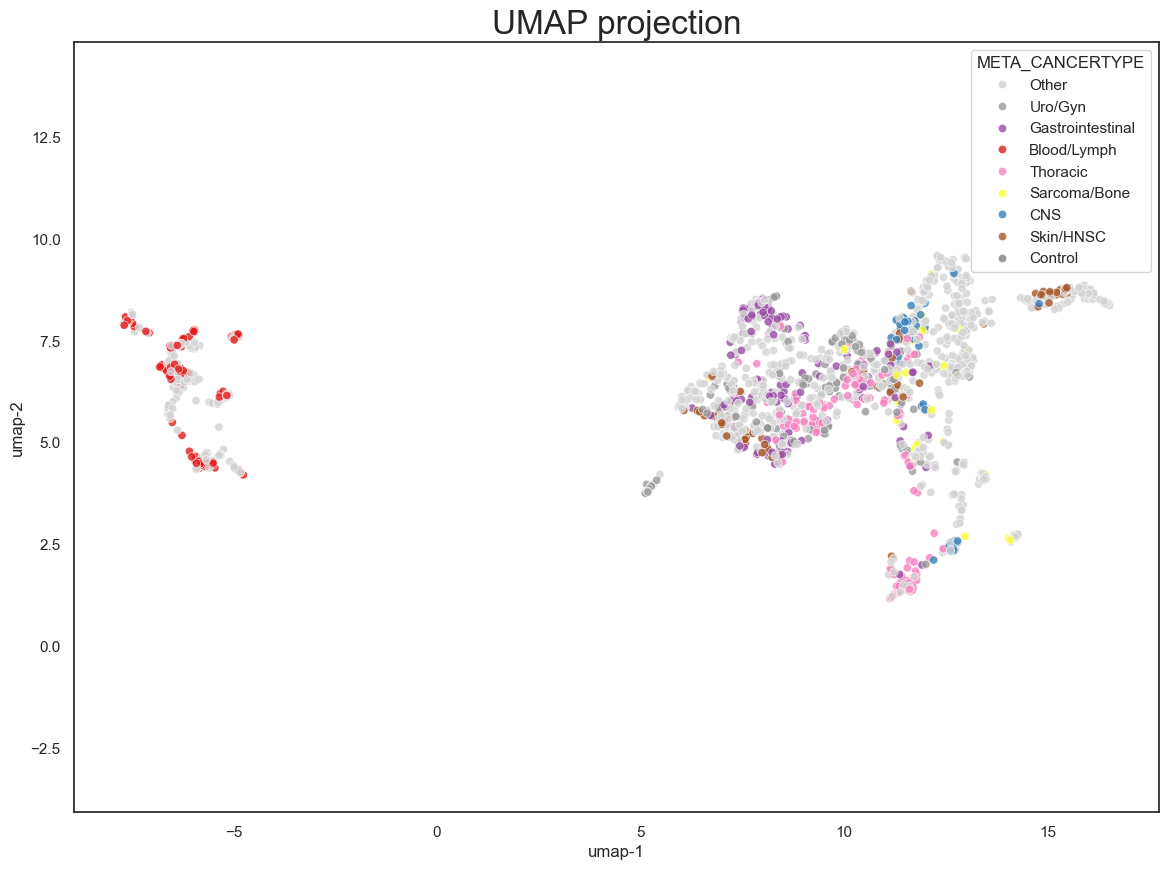

In [17]:
sns.scatterplot(
    x='umap-1', y='umap-2', 
    hue='META_CANCERTYPE', 
    data=pca_plot_df,
    palette=color_dict,
    alpha=0.8,
    edgecolor='w'
) 

plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection', fontsize=24);

### 3-dimensional

In [18]:
reducer = umap.UMAP(n_components=3)
embedding_3d = reducer.fit_transform(scaled_data)
embedding_3d.shape

(1754, 3)

In [19]:
import plotly.express as px

In [22]:
fig = px.scatter_3d(
    x=embedding_3d[:, 0],
    y=embedding_3d[:, 1],
    z=embedding_3d[:, 2],
    color=ge_matched['META_CANCERTYPE'],
    title='UMAP 3D Projection',
    labels={'color': 'Cancer Type'},
    opacity=0.8
)
fig.update_traces(marker=dict(size=3))
fig.show()

## Clustering for identifying co-sensitive cell lines and structurally related drug groups

### Co-sensitive cell lines

First clustering heatmap with gene expression data and cancer types

Pick genes with the biggest variance: $$ \sigma^2 = \frac{1}{N} \sum_{i=1}^{N} (x_i - \mu)^2 $$

I tested different things to deload the cell lines in the heatmap

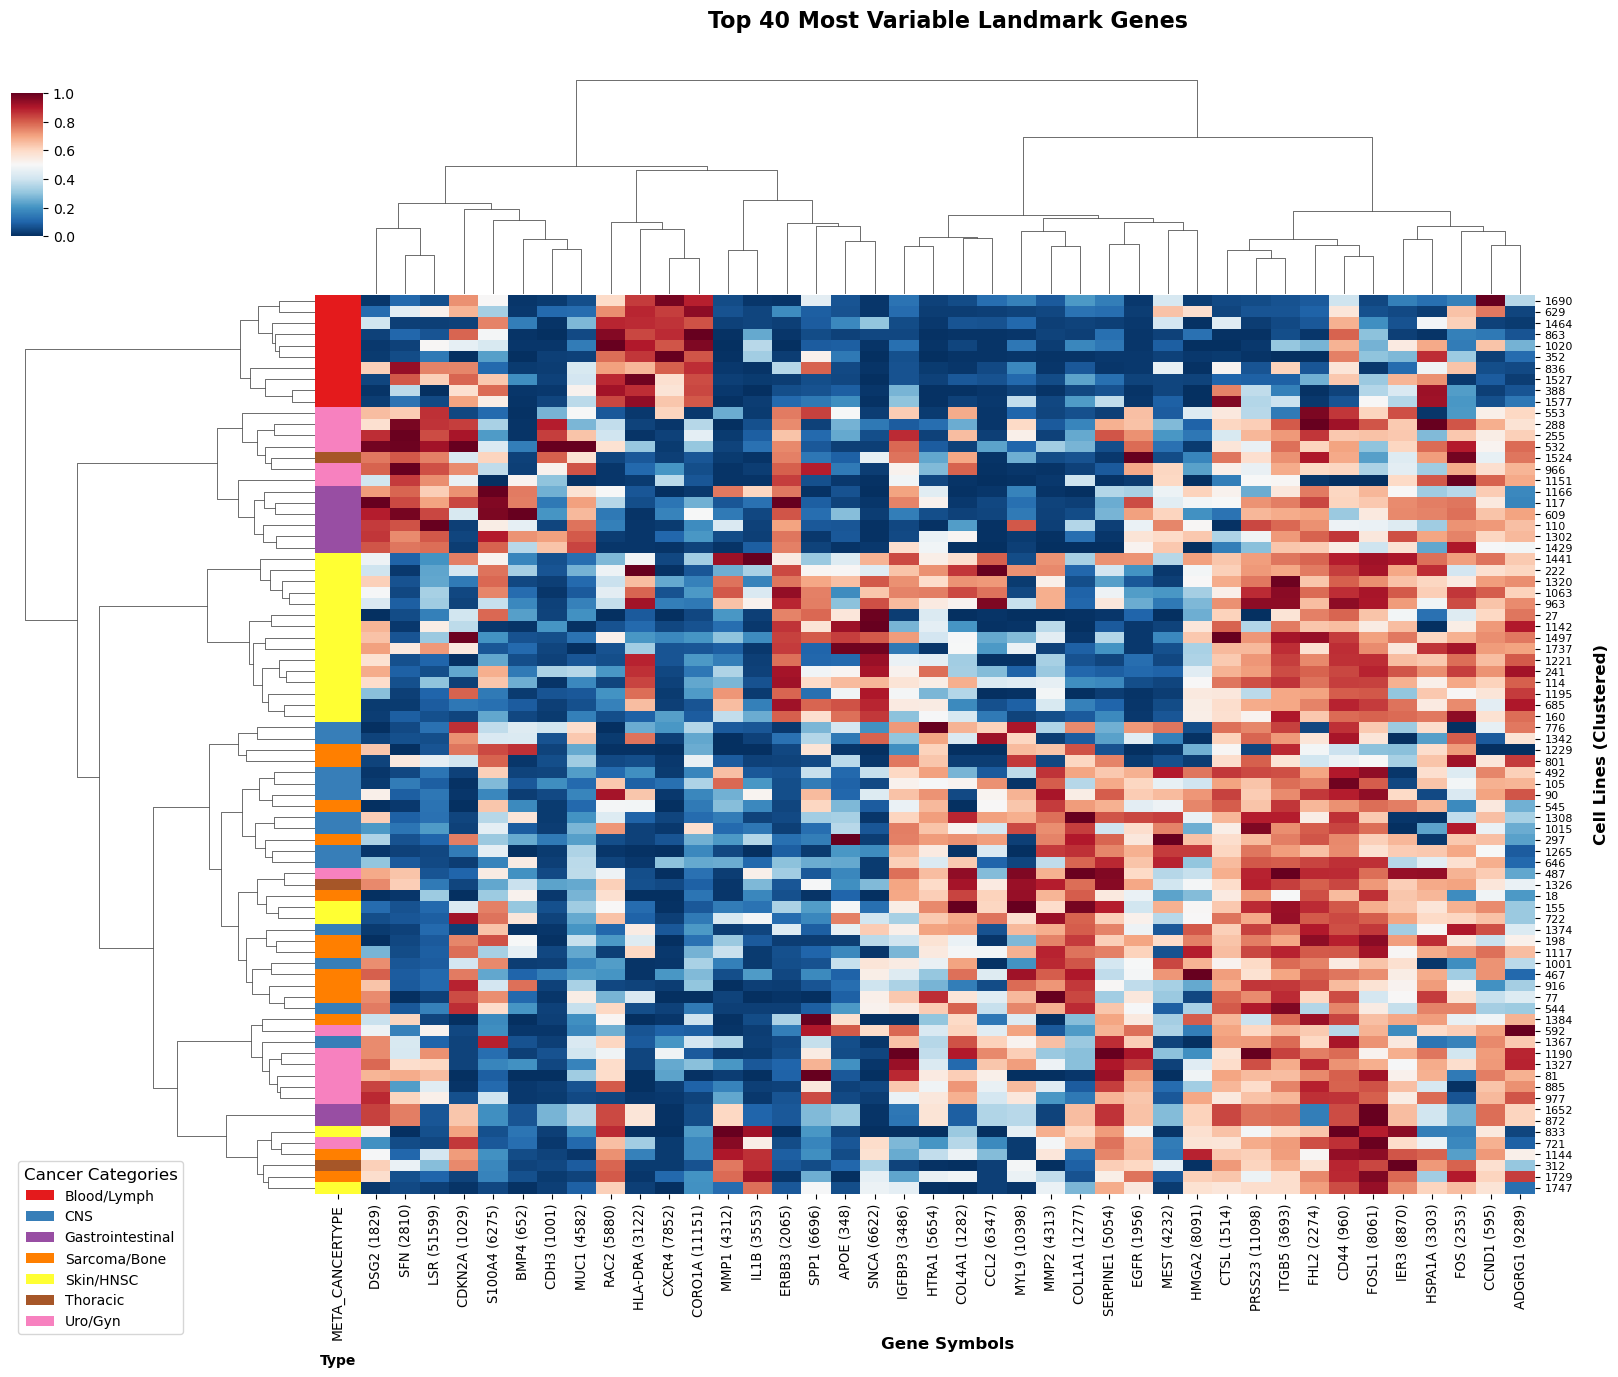

In [73]:
# Option 1: Group by cancer type and take a maximum of 12 random cell lines per group 
#df_balanced = ge_matched.groupby("META_CANCERTYPE").sample(n=12, random_state=42, replace=True).drop_duplicates()
# Prepare the expression matrix and top genes
expression_matrix = ge_matched[ge_matched['META_CANCERTYPE'] != 'Other'].filter(regex=r'.* \(.*\)')
highly_variable_genes = expression_matrix.var().sort_values(ascending=False).head(40).index
final_heatmap_data = expression_matrix[highly_variable_genes]
# Map the colors using the updated dictionary
final_row_colors = ge_matched["META_CANCERTYPE"].map(color_dict_filtered)
# Option 2: Filter out any cell line with low variance
row_dynamic_range = expression_matrix[highly_variable_genes].var(axis=1)
top_quality_cell_lines = row_dynamic_range.sort_values(ascending=False).head(80).index
df_final_qc = ge_matched.loc[top_quality_cell_lines]
final_heatmap_data = df_final_qc[highly_variable_genes]
final_row_colors = df_final_qc["META_CANCERTYPE"].map(color_dict_filtered)

# Create the Clustermap
cg = sns.clustermap(
    final_heatmap_data,
    metric="euclidean",
    method="ward",
    cmap="RdBu_r", 
    standard_scale=1,
    row_colors=final_row_colors,
    figsize=(16, 13),
    cbar_pos=(0.01, 0.86, 0.02, 0.11),
    yticklabels=True,
    xticklabels=True,
    rasterized=True
)

# 6. Formatting Labels
cg.ax_heatmap.set_xlabel("Gene Symbols", fontsize=12, fontweight='bold', labelpad=15)
cg.ax_heatmap.set_ylabel("Cell Lines (Clustered)", fontsize=12, fontweight='bold', labelpad=15)
plt.setp(cg.ax_heatmap.get_xticklabels(), rotation=90, fontsize=9.5)
plt.setp(cg.ax_heatmap.get_yticklabels(), fontsize=8)

# Clean up the row colors axis text 
cg.ax_row_colors.set_xlabel("Type", fontsize=10, fontweight='bold', labelpad=10) 
cg.ax_row_colors.xaxis.set_label_position('bottom')

# Position the Title
cg.ax_col_dendrogram.set_title("Top 40 Most Variable Landmark Genes", fontsize=16, fontweight='bold', pad=30)

# 7. Render the Legend (Now dynamically includes 'Other' since it's in the dict!)
legend_elements = [Patch(facecolor=color_dict_filtered[cat], label=cat) for cat in color_dict_filtered if cat in df_final_qc["META_CANCERTYPE"].unique()]
cg.figure.legend(
    handles=legend_elements, 
    title='Cancer Categories', 
    bbox_to_anchor=(0.01, 0.01),     
    loc='lower left',
    title_fontsize='large',
    frameon=True
)
plt.show()

Now I try to find cell lines that react similar to specific drugs.

In [3]:
from rdkit import Chem

In [76]:
master_df = pd.read_pickle(r"C:\Users\Juli\Documents\Master\Projekt Genomforschung\Datasets\harmonized_data.pkl")

Versuch, nach Co-Celllines zu clustern:

In [ ]:
# create the Drug-Response Matrix
pivot_df = master_df.pivot_table(
    index='SANGER_MODEL_ID', 
    columns='DRUG_NAME', 
    values='LN_IC50'
)

# handling Missing Values (Crucial for Clustering)
# Most clustering algorithms cannot handle NaNs. 
# We fill them with the mean of that specific drug.
pivot_df_filled = pivot_df.apply(lambda x: x.fillna(x.mean()), axis=0)

# add Cancer Type as a label for later
# We create a mapping from the original dataframe
id_to_cancer = master_df[['SANGER_MODEL_ID', 'CANCER_TYPE']].drop_duplicates().set_index('SANGER_MODEL_ID')

print(f"Pivot Matrix Shape: {pivot_df_filled.shape}")

Pivot Matrix Shape: (715, 286)


0 as minimum value for that drug (the most sensitive/lowest IC50​), 1 as maximum value for that drug (the most resistant/highest IC50​).

### Cluster to find structurally related drugs

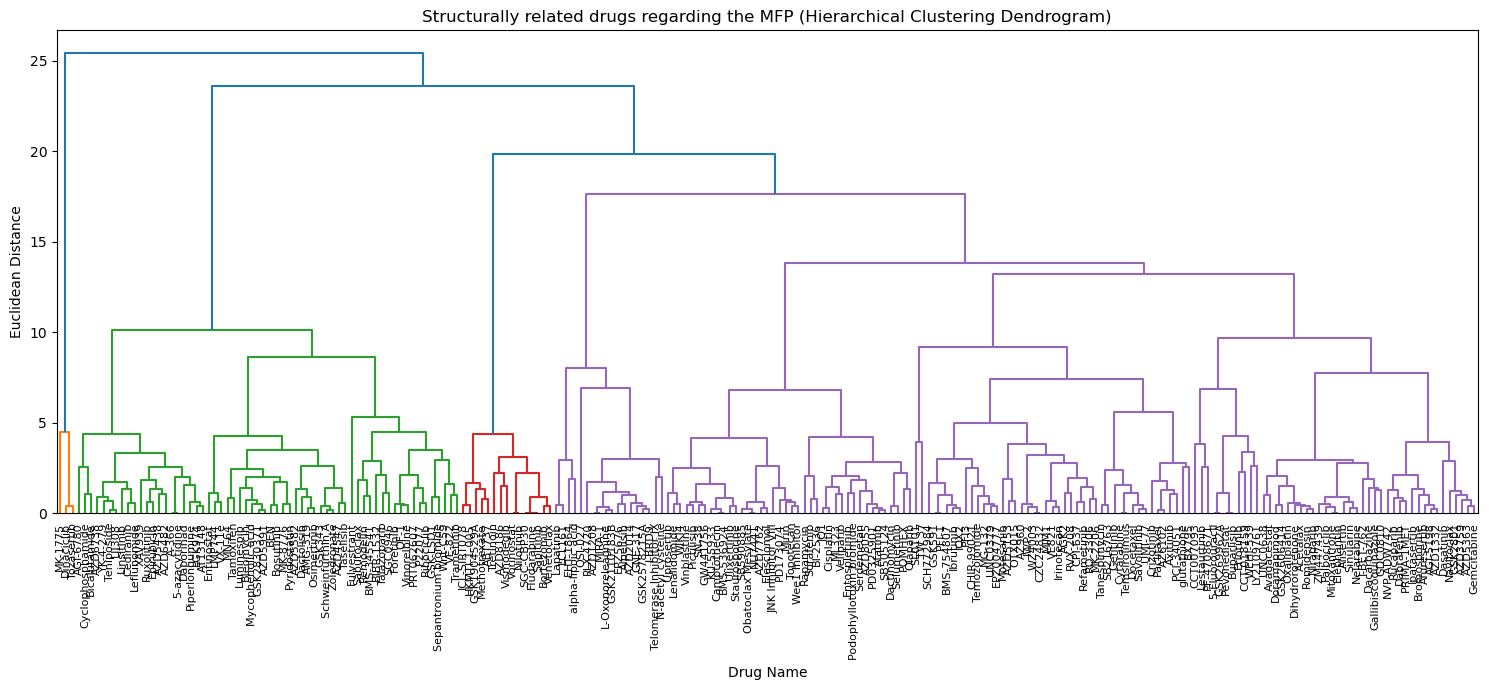

In [ ]:
# select only chemical feature columns
chem_cols = [c for c in master_df.columns if c.startswith('Bit_')]
print(chem_cols[:5])  # print first 5 chemical feature columns to verify
# get unique drugs to avoid redundant calculations
drug_structure_df = master_df[['DRUG_NAME', 'PharmacophoreFeatures'] + chem_cols]

df_temp = drug_structure_df.drop(columns=['PharmacophoreFeatures'])

# find unique indices
unique_indices = df_temp.drop_duplicates().index
drug_structure_df = drug_structure_df.loc[unique_indices].copy().set_index('DRUG_NAME')

# now scaling the pharmacore feature to distinct columns
# every key in the dict (e.g. 'Donor') becomes a column
pharmacophore_features = drug_structure_df['PharmacophoreFeatures'].apply(pd.Series)

# fill missing values with 0 (if a drug has no 'Donor' features, it should be 0, not NaN)
pharmacophore_features = pharmacophore_features.fillna(0)

X_final = pd.concat([drug_structure_df.drop(columns=['PharmacophoreFeatures']), pharmacophore_features], axis=1)

# make sure no strings/ids are included in the algorithm
X_clustering = X_final.select_dtypes(include=['number'])

# scaling (important because bits are 0/1, but pharmacophore counts can be higher)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

# compute the Linkage Matrix
# 'ward' method minimizes the variance within clusters
# 'euclidean' distance works well with scaled features
Z = linkage(X_scaled, method='ward', metric='euclidean')

# visualize the Drug Family Tree (Dendrogram)
plt.figure(figsize=(15, 7))
dendrogram(Z, labels=drug_structure_df.index, leaf_rotation=90, leaf_font_size=8)
plt.title("Structurally related drugs regarding the MFP (Hierarchical Clustering Dendrogram)")
plt.xlabel("Drug Name")
plt.ylabel("Euclidean Distance")
plt.tight_layout()
plt.show()

The dendrogram above shows an euclidian distance of ~0 in the left. It means that the drugs have basically the same structure according to the MFP. 
Perhaps I need to clean the dataset before using it for training.
I try to summarize the similar drugs to one thing.
There are 1596 drug with distance 0 in the dataset.

In [ ]:
# reset index (drug name)
df_for_agg = drug_structure_df.reset_index()

# create a list of all columns that start with 'Bit_' for aggregation
bit_cols = [col for col in df_for_agg.columns if col.startswith('Bit_')]

# define aggregation logic: for bit columns, we take the mean (which will be between 0 and 1, indicating the proportion of drugs in that cluster that have that bit)
agg_logic = {col: 'mean' for col in bit_cols}
agg_logic['DRUG_NAME'] = lambda x: "Drug clone" if len(set(x)) > 1 else list(set(x))[0]

# group by the bit columns and apply the aggregation logic
df_deduplicated = df_for_agg.groupby(bit_cols).agg(agg_logic).reset_index(drop=True)
df_deduplicated[bit_cols] = df_deduplicated[bit_cols].astype(int)

#df_deduplicated.set_index('DRUG_NAME', inplace=True)

ValueError: No group keys passed!

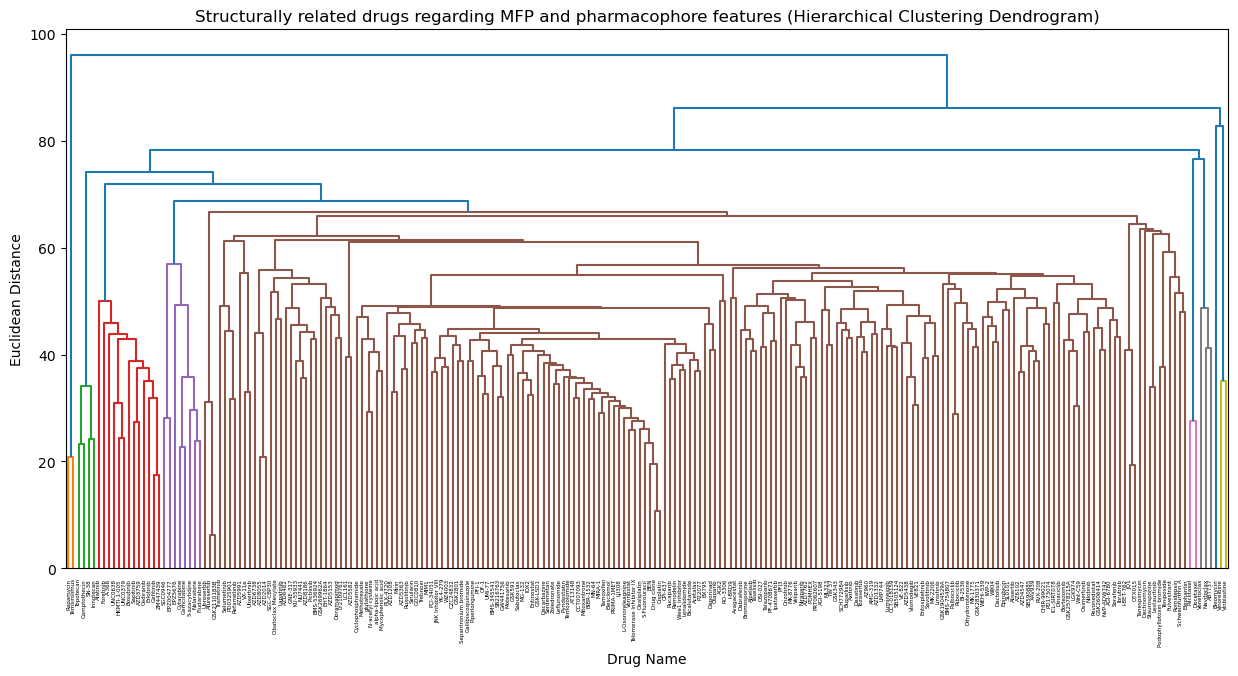

In [11]:
# scaling (important because bits are 0/1, but pharmacophore counts can be higher)
scaler = StandardScaler()
clone_scaled = scaler.fit_transform(df_deduplicated.drop(columns=['DRUG_NAME']))

# compute the Linkage Matrix
# 'ward' method minimizes the variance within clusters
# 'euclidean' distance works well with scaled features
Z = linkage(clone_scaled, method='ward', metric='euclidean')

# visualize the Drug Family Tree (Dendrogram)
plt.figure(figsize=(15, 7))
dendrogram(Z, labels=df_deduplicated['DRUG_NAME'].values, leaf_rotation=90, leaf_font_size=4)
plt.title("Structurally related drugs regarding MFP and pharmacophore features (Hierarchical Clustering Dendrogram)")
plt.xlabel("Drug Name")
plt.ylabel("Euclidean Distance")
#plt.tight_layout()
plt.show()

Now this is the dendrogramm without the drug clones, just summarized as one data point (above the 'a' in Name).